In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt

In [2]:
fake = pd.read_csv("fake_users.csv")
real = pd.read_csv("real_users.csv")

In [3]:
fake["label"] = 1
real["label"] = 0

In [4]:
df = pd.concat([fake, real], ignore_index=True)

print(df.head())
print(df.shape)

             id             name  screen_name  statuses_count  \
0  1.664073e+09    Lavona Keller    kellervxg       13.093733   
1  7.296345e+08  Elizabet Graves          NaN        0.000000   
2  1.214885e+09   Estelle Santos  estellesant       52.941642   
3 -0.000000e+00      Patsy Weiss     patsyyor       18.857321   
4  1.844412e+09       Cindy Cook          NaN       51.167110   

   followers_count  friends_count  favourites_count  listed_count  \
0        -0.000000       0.000000               0.0           0.0   
1         0.000000       0.000000               0.0           0.0   
2        -0.000000     518.508286              -0.0          -0.0   
3         0.000000    1059.138617               0.0           0.0   
4         7.368223       0.000000               0.0           0.0   

                       created_at  url  ...  \
0  Sun Jun 24 03:26:11 +0000 2012 -0.0  ...   
1  Mon Jun 25 02:06:59 +0000 2012  0.0  ...   
2  Sat Jun 23 19:48:28 +0000 2012 -0.0  ...   
3  Sat

In [5]:
drop_cols = [
    "id",
    "name",
    "screen_name",
    "profile_image_url",
    "profile_banner_url",
    "profile_image_url_https",
    "profile_background_image_url",
    "profile_background_image_url_https",
    "updated",
    "dataset"
]

for col in drop_cols:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

In [6]:
df.fillna("Unknown", inplace=True)

In [7]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype=="object":
        df[col]=le.fit_transform(df[col].astype(str))

In [8]:
X = df.drop("label", axis=1)
y = df["label"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [10]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

dt_pred = dt.predict(X_test)

In [11]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
lr = LogisticRegression(max_iter=5000, random_state=42)

lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [16]:
lr = LogisticRegression(max_iter=5000)

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)

In [17]:
def evaluate(name,y_test,pred):

    print("\n",name)

    print("Accuracy :",accuracy_score(y_test,pred))

    print("Precision :",precision_score(y_test,pred))

    print("Recall :",recall_score(y_test,pred))

    print("F1 Score :",f1_score(y_test,pred))

    print(confusion_matrix(y_test,pred))

    print(classification_report(y_test,pred))

    return accuracy_score(y_test,pred)

In [18]:
dt_acc = evaluate("Decision Tree",y_test,dt_pred)

rf_acc = evaluate("Random Forest",y_test,rf_pred)

lr_acc = evaluate("Logistic Regression",y_test,lr_pred)


 Decision Tree
Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0
[[500   0]
 [  0 500]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       500
           1       1.00      1.00      1.00       500

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


 Random Forest
Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0
[[500   0]
 [  0 500]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       500
           1       1.00      1.00      1.00       500

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


 Logistic Regression
Accuracy : 0.925
Precision : 0.8695652173913043
Recall : 1.0
F1 Score : 0.9302325581395349
[[425  75]
 [  0 500]]
              

In [19]:
result = pd.DataFrame({

    "Algorithm":[
        "Decision Tree",
        "Random Forest",
        "Logistic Regression"
    ],

    "Accuracy":[
        dt_acc,
        rf_acc,
        lr_acc
    ]

})

print(result)

             Algorithm  Accuracy
0        Decision Tree     1.000
1        Random Forest     1.000
2  Logistic Regression     0.925


In [20]:
best = result.loc[result["Accuracy"].idxmax()]

print(best)

Algorithm    Decision Tree
Accuracy               1.0
Name: 0, dtype: object


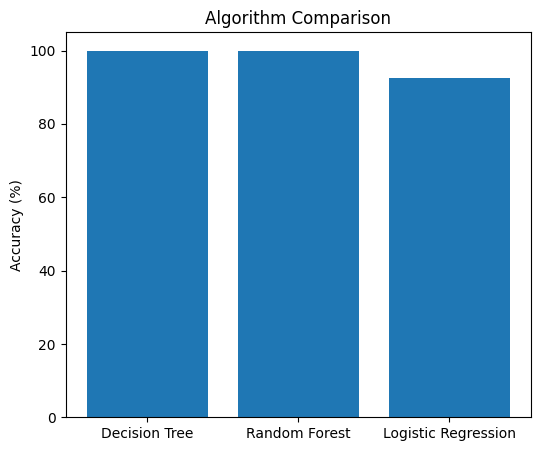

In [21]:
plt.figure(figsize=(6,5))

plt.bar(result["Algorithm"],result["Accuracy"]*100)

plt.ylabel("Accuracy (%)")

plt.title("Algorithm Comparison")

plt.show()

In [23]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [24]:
type(X_test)

numpy.ndarray

In [26]:
best_model = rf

sample = X_test[0].reshape(1, -1)

prediction = best_model.predict(sample)

if prediction[0] == 1:
    print("Fake Profile")
else:
    print("Genuine Profile")

Fake Profile


C:\Users\HP\anaconda3\envs\tfenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [27]:
# Load one genuine profile
genuine_profile = real.drop("label", axis=1).iloc[[0]]

# Apply the same preprocessing as used during training
for col in genuine_profile.columns:
    if genuine_profile[col].dtype == "object":
        genuine_profile[col] = le.fit_transform(genuine_profile[col].astype(str))

# Keep only the columns used during training
genuine_profile = genuine_profile[X.columns]

# Predict
prediction = rf.predict(genuine_profile)

if prediction[0] == 1:
    print("Fake Profile")
else:
    print("Genuine Profile")

Genuine Profile
